# Credit Card Default Prediction

## Project Goal
The goal of this project is to predict whether a credit card client will default on payment next month using demographic, billing, and repayment history variables.

## Why this matters
Default prediction is an important classification problem in financial risk analysis. A well-performing model can help identify higher-risk clients and support better lending decisions.

## Project workflow
This notebook covers:
- Data Loading and Cleaning
- Exploratory Data Analysis (EDA)
- Preprocessing and Feature Engineering
- Model Training and Comparison
- Final Evaluation and Interpretation

## Reference and Data Intro
The Default of Credit Card Clients dataset contains information on 30,000 credit card clients from a Taiwan-based bank. It includes demographic variables, credit limit, repayment status, bill statement amounts, and previous payment amounts. The target variable is whether the client defaults on payment in the following month, making it a binary classification problem commonly used in credit risk modeling.


**Citation:** Yeh, I. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.


<!-- BEGIN QUESTION -->

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
)

# Baseline model
from sklearn.dummy import DummyClassifier

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Feature selection and interpretation
from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance

# Evaluation metrics
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


In [ ]:
# Load Option 1 dataset:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
#Glance at the Data:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (30000, 25)

Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [ ]:
#List out the features and TARGET:
target_col = "default.payment.next.month"
X = df.drop(columns=[target_col])
y = df[target_col]

print("Target column:", target_col)
print("Number of features:", X.shape[1])
print("Target distribution:")
print(y.value_counts())
print("\nTarget proportion:")
print(y.value_counts(normalize=True).round(4))

Target column: default.payment.next.month
Number of features: 24
Target distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target proportion:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


#### Comments:
I chose Option 1, the Default of Credit Card Clients dataset for this mini-project. This is a binary classification problem where the goal is to predict whether a credit card client will default on their payment in the next month. In the dataset, the target variable is `default.payment.next.month`, where a value of 1 indicates default and 0 indicates no default.

This problem is meaningful because predicting default risk can help financial institutions make better decisions about lending, risk management, and customer support (That sounds pretty fun to me). The dataset includes customer demographic information such as age, sex, education, and marital status. Also credit limit information, repayment status history, bill amounts, and payment amounts. These variables can be used as features to predict the target.

I loaded the dataset into a pandas. Since the target column is already provided and the data is relatively clean, this dataset is a good fit for building and comparing supervised machine learning models in a reproducible way.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.30, 
    random_state = 123,
    stratify = y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21000, 24)
X_test shape: (9000, 24)
y_train shape: (21000,)
y_test shape: (9000,)


In [ ]:
print("Original target proportion:")
print(y.value_counts(normalize=True).round(4))

Original target proportion:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


#### Comments: 
I split the data into a training set (70%) and a test set (30%) using train_test_split with random_state=123 as required. I used stratify=y so that the class proportions are approximately preserved in both the training and test sets, since it is a classification problem with an imbalance target.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:


#Combine training features and target for EDA:
train_df = X_train.copy()
train_df["default.payment.next.month"] = y_train

print("Training set shape:", train_df.shape)
print("\nMissing values (top 10 columns):")
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nData types:")
print(train_df.dtypes.value_counts())

Training set shape: (21000, 25)

Missing values (top 10 columns):
ID           0
BILL_AMT2    0
PAY_AMT6     0
PAY_AMT5     0
PAY_AMT4     0
PAY_AMT3     0
PAY_AMT2     0
PAY_AMT1     0
BILL_AMT6    0
BILL_AMT5    0
dtype: int64

Data types:
float64    13
int64      12
Name: count, dtype: int64


In [ ]:
target_col = "default.payment.next.month"

print("Training target counts:")
print(train_df[target_col].value_counts())

print("\nTraining target proportions:")
print(train_df[target_col].value_counts(normalize=True).round(4))

Training target counts:
default.payment.next.month
0    16355
1     4645
Name: count, dtype: int64

Training target proportions:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


-- The target variable is clearly imbalanced in the training set, with 16,355 non-default cases (77.88%) and 4,645 default cases (22.12%), so model evaluation should not rely on accuracy alone.

In [ ]:
selected_cols = ["LIMIT_BAL", "AGE", "PAY_0", "BILL_AMT1", "PAY_AMT1"]

print(train_df[selected_cols].describe().T)

             count           mean            std       min       25%  \
LIMIT_BAL  21000.0  167627.318095  129860.863421   10000.0  50000.00   
AGE        21000.0      35.488476       9.224177      21.0     28.00   
PAY_0      21000.0      -0.017429       1.125270      -2.0     -1.00   
BILL_AMT1  21000.0   50978.436286   73097.849892 -154973.0   3517.75   
PAY_AMT1   21000.0    5663.359190   16612.876887       0.0   1000.00   

                50%        75%        max  
LIMIT_BAL  140000.0  240000.00  1000000.0  
AGE            34.0      41.00       79.0  
PAY_0           0.0       0.00        8.0  
BILL_AMT1   22485.5   67061.25   964511.0  
PAY_AMT1     2100.0    5001.00   873552.0  


-- The selected features show very different scales and wide ranges. For example, `LIMIT_BAL` ranges from 10,000 to 1,000,000 and `PAY_AMT1` ranges from 0 to 873,552, which suggests that scaling will likely be important for some models.

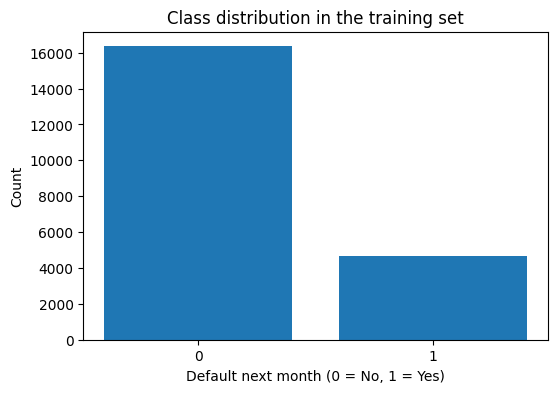

In [ ]:
#Visualization 1: class distribution bar chart
class_counts = train_df[target_col].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Default next month (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Class distribution in the training set")
plt.show()

-- The class distribution bar chart confirms a strong class imbalance, with the non-default class much larger than the default class.

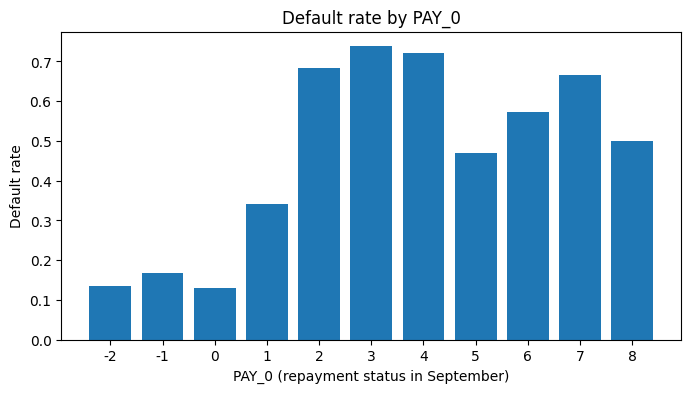

PAY_0
-2    0.134
-1    0.168
 0    0.129
 1    0.342
 2    0.684
 3    0.738
 4    0.722
 5    0.471
 6    0.571
 7    0.667
 8    0.500
Name: default.payment.next.month, dtype: float64


In [ ]:
#Visualization 2: default rate by repayment status
default_rate_by_pay0 = train_df.groupby("PAY_0")[target_col].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(default_rate_by_pay0.index.astype(str), default_rate_by_pay0.values)
plt.xlabel("PAY_0 (repayment status in September)")
plt.ylabel("Default rate")
plt.title("Default rate by PAY_0")
plt.show()

print(default_rate_by_pay0.round(3))

-- The default rate generally increases as `PAY_0` indicates worse recent repayment status. For example, around 0.129 at `PAY_0=0` versus `0.684 – 0.738` at `PAY_0=2` to 3, which shows that repayment status is likely a highly informative predictor.

#### Task 3:

The training dataset contains 21,000 rows and 25 columns, and the columns shown in the missing-value check have no missing values. The feature set includes both integer and float columns, and the variables are on very different numeric scales. I also observed that the target variable is imbalanced, which is about 78% non-default and 22% default, which means a naive model could appear to perform well if it mostly predicts the majority class. In addition, the relationship between `PAY_0` and the default rate suggests that repayment history features are likely to be among the most useful predictors in the modeling stage.


#### Task 4:

Because this is an imbalanced binary classification problem, I will use ROC-AUC and F1-score as my main evaluation metrics, and I will also examine precision and recall. ROC-AUC is useful because it measures how well the model separates the two classes across thresholds, while F1-score balances precision and recall and is more informative than accuracy when the classes are imbalanced.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [ ]:
def add_credit_features(df):
    df_fe = df.copy()

    pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
    pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

    #Repayment-status based features:
    df_fe["avg_pay_status"] = df_fe[pay_status_cols].mean(axis=1)
    df_fe["max_pay_status"] = df_fe[pay_status_cols].max(axis=1)
    df_fe["num_months_late"] = (df_fe[pay_status_cols] > 0).sum(axis=1)
    df_fe["any_month_late"] = (df_fe["num_months_late"] > 0).astype(int)

    #Bill / payment amount aggregate features:
    df_fe["avg_bill_amt"] = df_fe[bill_cols].mean(axis=1)
    df_fe["avg_pay_amt"] = df_fe[pay_amt_cols].mean(axis=1)
    df_fe["total_bill_amt"] = df_fe[bill_cols].sum(axis=1)
    df_fe["total_pay_amt"] = df_fe[pay_amt_cols].sum(axis=1)

    #Average bill relative to credit limit:
    df_fe["mean_bill_to_limit"] = df_fe[bill_cols].mean(axis=1) / df_fe["LIMIT_BAL"]

    #Total payment relative to positive billed amount:
    positive_bill_sum = df_fe[bill_cols].clip(lower=0).sum(axis=1)
    df_fe["pay_to_bill_ratio_total"] = df_fe["total_pay_amt"] / (positive_bill_sum + 1)

    #Simple trend feature:
    df_fe["recent_bill_change"] = df_fe["BILL_AMT1"] - df_fe["BILL_AMT6"]

    return df_fe

#Apply to train and test:
X_train_fe = add_credit_features(X_train)
X_test_fe = add_credit_features(X_test)

print("Original X_train shape:", X_train.shape)
print("Feature-engineered X_train shape:", X_train_fe.shape)

new_cols = [c for c in X_train_fe.columns if c not in X_train.columns]
print("\nNew features created:")
print(new_cols)

Original X_train shape: (21000, 24)
Feature-engineered X_train shape: (21000, 35)

New features created:
['avg_pay_status', 'max_pay_status', 'num_months_late', 'any_month_late', 'avg_bill_amt', 'avg_pay_amt', 'total_bill_amt', 'total_pay_amt', 'mean_bill_to_limit', 'pay_to_bill_ratio_total', 'recent_bill_change']


#### Task 1:
I performed feature engineering by creating new features that summarize repayment behavior, billing amounts, and payment behavior across multiple months. The new features are described in the comments.

These features are relevant because they capture patterns such as how often a client was late, how severe the repayment delay was, how large the bills are relative to the credit limit, and how much the client tends to pay relative to billed amounts. 

After feature engineering, the number of training features increased from 24 to 35. I applied the same feature engineering function to both the training and test sets so the updated feature set can be used consistently.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [ ]:


id_cols = [col for col in ["ID"] if col in X_train_fe.columns]

categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X_train_fe.columns]

numeric_cols = [col for col in X_train_fe.columns if col not in id_cols + categorical_cols]

print("ID columns (to drop):", id_cols)
print("Categorical columns (one-hot):", categorical_cols)
print("Number of numeric columns (scale):", len(numeric_cols))
print("\nFirst 10 numeric columns:", numeric_cols[:10])

ID columns (to drop): ['ID']
Categorical columns (one-hot): ['SEX', 'EDUCATION', 'MARRIAGE']
Number of numeric columns (scale): 31

First 10 numeric columns: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2']


In [ ]:
#Define:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("drop_id", "drop", id_cols)
    ],
    remainder="drop"
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6', 'avg_pay_status',
                                  'max_pay_status', 'num_months_late',
                                  'any_month_late', 'avg_bill_amt',
                                  'avg_pay_amt', 'total_bill_amt',
                                  'total_pay_amt', 'mean_bill_to_limit',
        

In [ ]:
X_train_preprocessed = preprocessor.fit_transform(X_train_fe)
X_test_preprocessed = preprocessor.transform(X_test_fe)

print("Preprocessed X_train shape:", X_train_preprocessed.shape)
print("Preprocessed X_test shape:", X_test_preprocessed.shape)

Preprocessed X_train shape: (21000, 44)
Preprocessed X_test shape: (9000, 44)


#### Small Conclude:

I implemented these transformations using a `ColumnTransformer`, which combines the numeric and categorical preprocessing pipelines into one object. Even though the dataset appears to have no missing values, I included imputation steps to make the preprocessing pipeline more robust. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [ ]:


baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

In [ ]:
baseline_cv = cross_validate(
    baseline_pipe,
    X_train_fe,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

baseline_cv

{'fit_time': array([0.04498601, 0.0440619 , 0.04296684, 0.04190397, 0.04175305]),
 'score_time': array([0.01184297, 0.01129293, 0.01121092, 0.01118803, 0.01110983]),
 'test_accuracy': array([0.77880952, 0.77880952, 0.77880952, 0.77880952, 0.77880952]),
 'test_precision': array([0., 0., 0., 0., 0.]),
 'test_recall': array([0., 0., 0., 0., 0.]),
 'test_f1': array([0., 0., 0., 0., 0.]),
 'test_roc_auc': array([0.5, 0.5, 0.5, 0.5, 0.5])}

In [ ]:
baseline_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean_cv_score": [
        baseline_cv["test_accuracy"].mean(),
        baseline_cv["test_precision"].mean(),
        baseline_cv["test_recall"].mean(),
        baseline_cv["test_f1"].mean(),
        baseline_cv["test_roc_auc"].mean()
    ],
    "std_cv_score": [
        baseline_cv["test_accuracy"].std(),
        baseline_cv["test_precision"].std(),
        baseline_cv["test_recall"].std(),
        baseline_cv["test_f1"].std(),
        baseline_cv["test_roc_auc"].std()
    ]
})

baseline_summary.round(4)

,metric,mean_cv_score,std_cv_score
0,accuracy,0.7788,0.0
1,precision,0.0000,0.0
2,recall,0.0000,0.0
3,f1,0.0000,0.0
4,roc_auc,0.5000,0.0


#### Comments on Baseline:

I established a baseline model using scikit-learn’s DummyClassifier with strategy="most_frequent", which always predicts the majority class. I evaluated the baseline using 5-fold stratified cross-validation on the training set and reported the same metrics that I plan to use for later models.

The baseline achieved an accuracy of about 0.7788, which is high only because the dataset is imbalanced and the majority class is common. However, its precision, recall, and F1-score for the default class were all 0, because it never predicts the positive class. Its ROC-AUC was 0.50, which indicates no discriminative ability. This baseline is useful because it shows that a model must improve on more than just accuracy to be considered meaningful on this problem.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:


logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=123
    ))
])

param_grid_logreg = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

In [ ]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid_logreg,
    scoring=scoring,   
    refit="roc_auc",
    cv=cv, 
    n_jobs=-1,
    return_train_score=True
)

logreg_grid.fit(X_train_fe, y_train)

print("Best parameters:", logreg_grid.best_params_)
print("Best CV ROC-AUC:", round(logreg_grid.best_score_, 4))

Best parameters: {'model__C': 100}
Best CV ROC-AUC: 0.7579


In [ ]:
logreg_results = pd.DataFrame(logreg_grid.cv_results_)

cols_to_show = [
    "param_model__C",
    "mean_test_roc_auc", "std_test_roc_auc",
    "mean_test_f1", "std_test_f1",
    "mean_test_precision", "std_test_precision",
    "mean_test_recall", "std_test_recall",
    "mean_test_accuracy", "std_test_accuracy"
]

logreg_tuning_summary = logreg_results[cols_to_show].sort_values(by="mean_test_roc_auc", ascending=False)
logreg_tuning_summary.round(4)

,param_model__C,mean_test_roc_auc,std_test_roc_auc,mean_test_f1,std_test_f1,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_accuracy,std_test_accuracy
5,100.000,0.7579,0.0093,0.4063,0.0098,0.6471,0.0128,0.2962,0.0093,0.8086,0.0024
4,10.000,0.7579,0.0093,0.4063,0.0098,0.6471,0.0128,0.2962,0.0093,0.8086,0.0024
3,1.000,0.7579,0.0092,0.4057,0.0097,0.6469,0.0123,0.2956,0.0093,0.8085,0.0023
2,0.100,0.7576,0.0088,0.4048,0.0112,0.6488,0.0162,0.2943,0.0104,0.8086,0.0030
1,0.010,0.7547,0.0077,0.4055,0.0084,0.6499,0.0140,0.2947,0.0076,0.8089,0.0025
0,0.001,0.7439,0.0049,0.4059,0.0121,0.6477,0.0170,0.2956,0.0102,0.8086,0.0034


In [ ]:
best_idx = logreg_grid.best_index_

linear_best_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean_cv_score": [
        logreg_results.loc[best_idx, "mean_test_accuracy"],
        logreg_results.loc[best_idx, "mean_test_precision"],
        logreg_results.loc[best_idx, "mean_test_recall"],
        logreg_results.loc[best_idx, "mean_test_f1"],
        logreg_results.loc[best_idx, "mean_test_roc_auc"]
    ],
    "std_cv_score": [
        logreg_results.loc[best_idx, "std_test_accuracy"],
        logreg_results.loc[best_idx, "std_test_precision"],
        logreg_results.loc[best_idx, "std_test_recall"],
        logreg_results.loc[best_idx, "std_test_f1"],
        logreg_results.loc[best_idx, "std_test_roc_auc"]
    ]
})

linear_best_summary.round(4)

,metric,mean_cv_score,std_cv_score
0,accuracy,0.8086,0.0024
1,precision,0.6471,0.0128
2,recall,0.2962,0.0093
3,f1,0.4063,0.0098
4,roc_auc,0.7579,0.0093


In [ ]:
best_linear_model = logreg_grid.best_estimator_
best_linear_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

#### Summarize:

I trained a logistic regression model as my first real model for this binary classification problem. Logistic regression is a linear model for classification and is a strong benchmark because it is simple, interpretable, and works well with standardized numerical features and one-hot encoded categorical features.

I tuned the model’s complexity parameter C using 5-fold stratified cross-validation and selected the best model based on ROC-AUC. The best hyperparameter value was C = 100, with a best cross-validation ROC-AUC of 0.7579.

For the best linear model, the cross-validation performance was approximately: accuracy = 0.8086 ± 0.0024, precision = 0.6471 ± 0.0128, recall = 0.2962 ± 0.0093, F1-score = 0.4063 ± 0.0098, and ROC-AUC = 0.7579 ± 0.0093. Compared with the DummyClassifier baseline, the logistic regression model substantially improved ROC-AUC, precision, recall, and F1-score, showing that it learned meaningful patterns rather than simply predicting the majority class.

From the tuning results, I observed that performance was fairly stable across the tested values of C, with the best ROC-AUC values for C = 10 and C = 100 being essentially the same. This suggests that the model is not highly sensitive to regularization within this range. Overall, logistic regression provides a strong and efficient linear benchmark for comparison with more complex models in the next section.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [ ]:

nonlinear_models = {
    "DecisionTree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=123))
    ]),
    
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=15))
    ]),
    
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=123,
            n_jobs=-1
        ))
    ])
}

nonlinear_models

{'DecisionTree': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                    'PAY_2', 'PAY_3', 'PAY_4',
                                                    'PAY_5', 'PAY_6',
                                                    'BILL_AMT1', 'BILL_AMT2',
                                                    'BILL_AMT3', 'BILL_AMT4',
                                                    'BILL_AMT5', 'BILL_AMT6',
                                                    'PAY_AMT1', 'PAY_AMT2',
   

In [ ]:


nonlinear_cv_results = {}
nonlinear_rows = []

for model_name, model_pipe in nonlinear_models.items():
    cv_result = cross_validate(
        model_pipe,
        X_train_fe,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )
    
    nonlinear_cv_results[model_name] = cv_result
    
    nonlinear_rows.append({
        "model": model_name,
        
        #timing
        "fit_time_mean": cv_result["fit_time"].mean(),
        "score_time_mean": cv_result["score_time"].mean(),
        
        #validation metrics
        "test_accuracy_mean": cv_result["test_accuracy"].mean(),
        "test_precision_mean": cv_result["test_precision"].mean(),
        "test_recall_mean": cv_result["test_recall"].mean(),
        "test_f1_mean": cv_result["test_f1"].mean(),
        "test_roc_auc_mean": cv_result["test_roc_auc"].mean(),
        
        #train metrics
        "train_accuracy_mean": cv_result["train_accuracy"].mean(),
        "train_f1_mean": cv_result["train_f1"].mean(),
        "train_roc_auc_mean": cv_result["train_roc_auc"].mean(),
        
        #std of validation metrics
        "test_f1_std": cv_result["test_f1"].std(),
        "test_roc_auc_std": cv_result["test_roc_auc"].std()
    })

nonlinear_summary = pd.DataFrame(nonlinear_rows)
nonlinear_summary

,model,fit_time_mean,score_time_mean,test_accuracy_mean,test_precision_mean,test_recall_mean,test_f1_mean,test_roc_auc_mean,train_accuracy_mean,train_f1_mean,train_roc_auc_mean,test_f1_std,test_roc_auc_std
0,DecisionTree,0.430198,0.012819,0.722333,0.380752,0.408611,0.394154,0.610314,0.999560,0.999003,0.999999,0.016887,0.010449
1,KNN,0.043935,0.175731,0.808571,0.622949,0.340797,0.440413,0.739948,0.822226,0.481970,0.823213,0.013645,0.003405
2,RandomForest,2.017447,0.116984,0.814095,0.635916,0.373089,0.470246,0.769116,0.999560,0.999004,0.999996,0.010742,0.004506


In [ ]:
nonlinear_summary["roc_auc_gap_train_minus_test"] = (
    nonlinear_summary["train_roc_auc_mean"] - nonlinear_summary["test_roc_auc_mean"]
)

nonlinear_summary["f1_gap_train_minus_test"] = (
    nonlinear_summary["train_f1_mean"] - nonlinear_summary["test_f1_mean"]
)

nonlinear_summary_sorted = nonlinear_summary.sort_values(
    by="test_roc_auc_mean", ascending=False
)

nonlinear_summary_sorted.round(4)

,model,fit_time_mean,score_time_mean,test_accuracy_mean,test_precision_mean,test_recall_mean,test_f1_mean,test_roc_auc_mean,train_accuracy_mean,train_f1_mean,train_roc_auc_mean,test_f1_std,test_roc_auc_std,roc_auc_gap_train_minus_test,f1_gap_train_minus_test
2,RandomForest,2.0174,0.1170,0.8141,0.6359,0.3731,0.4702,0.7691,0.9996,0.999,1.0000,0.0107,0.0045,0.2309,0.5288
1,KNN,0.0439,0.1757,0.8086,0.6229,0.3408,0.4404,0.7399,0.8222,0.482,0.8232,0.0136,0.0034,0.0833,0.0416
0,DecisionTree,0.4302,0.0128,0.7223,0.3808,0.4086,0.3942,0.6103,0.9996,0.999,1.0000,0.0169,0.0104,0.3897,0.6048


In [ ]:
#Extract best linear model CV metrics from Q7 table:
linear_metrics = linear_best_summary.set_index("metric")["mean_cv_score"].to_dict()

linear_comparison = pd.DataFrame({
    "model": ["LogisticRegression (best linear)"],
    "test_accuracy_mean": [linear_metrics["accuracy"]],
    "test_precision_mean": [linear_metrics["precision"]],
    "test_recall_mean": [linear_metrics["recall"]],
    "test_f1_mean": [linear_metrics["f1"]],
    "test_roc_auc_mean": [linear_metrics["roc_auc"]]
})

comparison_table = pd.concat([
    linear_comparison,
    nonlinear_summary_sorted[[
        "model", "test_accuracy_mean", "test_precision_mean",
        "test_recall_mean", "test_f1_mean", "test_roc_auc_mean"
    ]]
], ignore_index=True)

comparison_table.round(4)

,model,test_accuracy_mean,test_precision_mean,test_recall_mean,test_f1_mean,test_roc_auc_mean
0,LogisticRegression (best linear),0.8086,0.6471,0.2962,0.4063,0.7579
1,RandomForest,0.8141,0.6359,0.3731,0.4702,0.7691
2,KNN,0.8086,0.6229,0.3408,0.4404,0.7399
3,DecisionTree,0.7223,0.3808,0.4086,0.3942,0.6103


In [ ]:
best_nonlinear_name = nonlinear_summary_sorted.iloc[0]["model"]
print("Best non-linear model by CV ROC-AUC:", best_nonlinear_name)

Best non-linear model by CV ROC-AUC: RandomForest


#### Summarize:

I experimented with three non-linear models: Decision Tree, KNN, and Random Forest. I evaluated all models using the same 5-fold stratified cross-validation setup and the same metrics as in previous sections so that the comparison with the linear model would be fair.

Based on the cross-validation results, the best-performing non-linear model in terms of ROC-AUC was Random Forest, with a mean ROC-AUC of 0.7691 and mean F1-score of 0.4702. The KNN model achieved a mean ROC-AUC of 0.7399 and mean F1-score of 0.4404, while the Decision Tree model achieved a mean ROC-AUC of 0.6103 and mean F1-score of 0.3942. In comparison, the best linear model had a mean ROC-AUC of 0.7579 and mean F1-score of 0.4063.

In terms of overfitting and underfitting behavior, the Decision Tree showed strong overfitting. Its training accuracy was extremely high, about 0.9996, while its validation accuracy dropped to 0.7223, and its validation ROC-AUC was much lower than the other models. This indicates that the single tree fit the training data too closely and generalized poorly. The KNN model showed much less overfitting and produced reasonable performance, but it did not outperform logistic regression on ROC-AUC. The Random Forest model also showed some overfitting (very high training accuracy), but it generalized much better than the single Decision Tree and achieved the best validation performance overall.

Regarding computation time, KNN had the fastest fit time of 0.0466s but the slowest score time of 0.1992s because prediction requires distance calculations. Random Forest had the slowest fit time of about 2.0236s but a moderate score time of 0.1161s. Decision Tree had a moderate fit time of 0.4316s and the fastest score time of 0.0138s.

Overall, Random Forest improved accuracy (0.8141 vs 0.8086), recall (0.3731 vs 0.2962), F1-score (0.4702 vs 0.4063), and ROC-AUC (0.7691 vs 0.7579) compared with logistic regression, although its precision (0.6359) was slightly lower than logistic regression (0.6471). This comparison highlights useful trade-offs between predictive performance, overfitting risk, and computational cost.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [ ]:


rfecv_estimator = LogisticRegression(
    C=100,             
    max_iter=2000,
    solver="liblinear",
    random_state=123
)

#RFECV:
rfecv = RFECV(
    estimator=rfecv_estimator,
    step=2,                     
    min_features_to_select=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=123),
    scoring="roc_auc",
    n_jobs=-1
)

logreg_fs_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", rfecv),
    ("model", LogisticRegression(
        C=100,
        max_iter=2000,
        solver="liblinear",
        random_state=123
    ))
])

logreg_fs_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [ ]:
logreg_fs_cv = cross_validate(
    logreg_fs_pipe,
    X_train_fe,
    y_train,
    cv=cv, 
    scoring=scoring,
    return_train_score=True
)

logreg_fs_cv

{'fit_time': array([2.68234086, 2.11339784, 2.59081602, 2.55877399, 2.77803421]),
 'score_time': array([0.0132761 , 0.01335406, 0.01349998, 0.01858473, 0.01305079]),
 'test_accuracy': array([0.81071429, 0.80738095, 0.80595238, 0.81166667, 0.80619048]),
 'train_accuracy': array([0.8075    , 0.80964286, 0.80970238, 0.80821429, 0.81083333]),
 'test_precision': array([0.65509259, 0.6369863 , 0.64179104, 0.66197183, 0.63218391]),
 'train_precision': array([0.64465786, 0.6509324 , 0.65219941, 0.64546525, 0.65389016]),
 'test_recall': array([0.30462863, 0.30032293, 0.27771798, 0.30355221, 0.29601722]),
 'train_recall': array([0.28902045, 0.30059203, 0.2992465 , 0.2949408 , 0.30758881]),
 'test_f1': array([0.41587068, 0.40819312, 0.38767844, 0.41623616, 0.40322581]),
 'train_f1': array([0.39910814, 0.41126657, 0.41025641, 0.40487625, 0.41837482]),
 'test_roc_auc': array([0.77151215, 0.75127972, 0.7620963 , 0.75926225, 0.74423046]),
 'train_roc_auc': array([0.75804931, 0.7635233 , 0.76032376, 0

In [ ]:
fs_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean_cv_score": [
        logreg_fs_cv["test_accuracy"].mean(),
        logreg_fs_cv["test_precision"].mean(),
        logreg_fs_cv["test_recall"].mean(),
        logreg_fs_cv["test_f1"].mean(),
        logreg_fs_cv["test_roc_auc"].mean()
    ],
    "std_cv_score": [
        logreg_fs_cv["test_accuracy"].std(),
        logreg_fs_cv["test_precision"].std(),
        logreg_fs_cv["test_recall"].std(),
        logreg_fs_cv["test_f1"].std(),
        logreg_fs_cv["test_roc_auc"].std()
    ]
})

fs_summary.round(4)

,metric,mean_cv_score,std_cv_score
0,accuracy,0.8084,0.0024
1,precision,0.6456,0.0112
2,recall,0.2964,0.0098
3,f1,0.4062,0.0105
4,roc_auc,0.7577,0.0093


In [ ]:
#Q7 best logistic regression results are stored in linear_best_summary:
before_fs_summary = linear_best_summary.copy()
before_fs_summary["version"] = "Before feature selection"

after_fs_summary = fs_summary.copy()
after_fs_summary["version"] = "After feature selection"

feature_selection_comparison = pd.concat(
    [before_fs_summary, after_fs_summary],
    ignore_index=True
)

feature_selection_comparison = feature_selection_comparison[["version", "metric", "mean_cv_score", "std_cv_score"]]
feature_selection_comparison.round(4)

,version,metric,mean_cv_score,std_cv_score
0,Before feature selection,accuracy,0.8086,0.0024
1,Before feature selection,precision,0.6471,0.0128
2,Before feature selection,recall,0.2962,0.0093
3,Before feature selection,f1,0.4063,0.0098
4,Before feature selection,roc_auc,0.7579,0.0093
5,After feature selection,accuracy,0.8084,0.0024
6,After feature selection,precision,0.6456,0.0112
7,After feature selection,recall,0.2964,0.0098
8,After feature selection,f1,0.4062,0.0105
9,After feature selection,roc_auc,0.7577,0.0093


In [ ]:
#Fit once on the full training set to inspect what RFECV selected:
logreg_fs_pipe.fit(X_train_fe, y_train)

fitted_preprocessor = logreg_fs_pipe.named_steps["preprocessor"]
fitted_selector = logreg_fs_pipe.named_steps["selector"]

feature_names_after_preprocessing = fitted_preprocessor.get_feature_names_out()

selected_mask = fitted_selector.support_
selected_feature_names = feature_names_after_preprocessing[selected_mask]

print("Number of features after preprocessing:", len(feature_names_after_preprocessing))
print("Number of selected features:", fitted_selector.n_features_)
print("\nSelected features:")
print(selected_feature_names)

Number of features after preprocessing: 44
Number of selected features: 40

Selected features:
['num__LIMIT_BAL' 'num__AGE' 'num__PAY_0' 'num__PAY_2' 'num__PAY_3'
 'num__PAY_4' 'num__PAY_5' 'num__PAY_6' 'num__BILL_AMT1' 'num__BILL_AMT2'
 'num__BILL_AMT3' 'num__BILL_AMT4' 'num__BILL_AMT5' 'num__BILL_AMT6'
 'num__PAY_AMT1' 'num__PAY_AMT2' 'num__PAY_AMT3' 'num__PAY_AMT6'
 'num__avg_pay_status' 'num__num_months_late' 'num__any_month_late'
 'num__avg_bill_amt' 'num__avg_pay_amt' 'num__total_bill_amt'
 'num__total_pay_amt' 'num__mean_bill_to_limit' 'num__recent_bill_change'
 'cat__SEX_1' 'cat__SEX_2' 'cat__EDUCATION_0' 'cat__EDUCATION_1'
 'cat__EDUCATION_2' 'cat__EDUCATION_3' 'cat__EDUCATION_4'
 'cat__EDUCATION_5' 'cat__EDUCATION_6' 'cat__MARRIAGE_0' 'cat__MARRIAGE_1'
 'cat__MARRIAGE_2' 'cat__MARRIAGE_3']


#### Summarize:

I performed feature selection using RFECV with logistic regression as the estimator and ROC-AUC as the selection metric. I placed RFECV inside a pipeline with the preprocessor so that feature selection was performed only on the training folds during cross-validation, which helps avoid data leakage.

RFECV selected 40 features out of 44 preprocessed features. I then compared the logistic regression model performance before and after feature selection using the same 5-fold stratified cross-validation setup. Before feature selection, the logistic regression model had ROC-AUC = 0.7579 and F1-score = 0.4063. After feature selection, the model achieved ROC-AUC = 0.7577 and F1-score = 0.4062.

The results stayed almost the same, with a very small decrease in ROC-AUC and F1-score after feature selection. Accuracy also changed only slightly about 0.8086 to 0.8084, and precision/recall remained nearly unchanged. Based on this comparison, I will NOT keep feature selection in the pipeline for the next sections because it did not provide a meaningful performance improvement and the original pipeline is simpler.

Even though the performance change was negligible, this experiment was still useful because it showed that the logistic regression model was already using a feature set that was not heavily hurt by a small amount of redundancy.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:

cv_q10 = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)
# -----------------------------
# 1) Logistic Regression search
# -----------------------------
logreg_tune_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=123
    ))
])

logreg_tune_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

logreg_search = GridSearchCV(
    estimator=logreg_tune_pipe,
    param_grid=logreg_tune_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv_q10,
    n_jobs=-1,
    return_train_score=True
)

# -----------------------------
# 2) KNN search
# -----------------------------
knn_tune_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_tune_grid = {
    "model__n_neighbors": [10, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_tune_pipe,
    param_grid=knn_tune_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv_q10,
    n_jobs=-1,
    return_train_score=True
)

# -----------------------------
# 3) Random Forest search
# -----------------------------
rf_tune_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune_pipe,
    param_distributions=rf_param_dist,
    n_iter=6,
    scoring=scoring,
    refit="roc_auc",
    cv=cv_q10,
    random_state=123,
    n_jobs=-1,
    return_train_score=True
)

print("Search objects created.")

Search objects created.


In [ ]:
logreg_search.fit(X_train_fe, y_train)

print("LogisticRegression best params:", logreg_search.best_params_)
print("LogisticRegression best CV ROC-AUC:", round(logreg_search.best_score_, 4))

LogisticRegression best params: {'model__C': 100, 'model__class_weight': 'balanced'}
LogisticRegression best CV ROC-AUC: 0.7596


In [ ]:
knn_search.fit(X_train_fe, y_train)

print("KNN best params:", knn_search.best_params_)
print("KNN best CV ROC-AUC:", round(knn_search.best_score_, 4))

KNN best params: {'model__n_neighbors': 25, 'model__p': 1, 'model__weights': 'uniform'}
KNN best CV ROC-AUC: 0.7581


In [ ]:
rf_search.fit(X_train_fe, y_train)

print("RandomForest best params:", rf_search.best_params_)
print("RandomForest best CV ROC-AUC:", round(rf_search.best_score_, 4))

RandomForest best params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}
RandomForest best CV ROC-AUC: 0.7822


In [ ]:
def summarize_search(search_obj, model_name):
    results = pd.DataFrame(search_obj.cv_results_)
    best_idx = search_obj.best_index_
    
    row = {
        "model": model_name,
        "best_params": search_obj.best_params_,
        "fit_time_mean_best": results.loc[best_idx, "mean_fit_time"],
        "score_time_mean_best": results.loc[best_idx, "mean_score_time"],
        
        "cv_accuracy_mean": results.loc[best_idx, "mean_test_accuracy"],
        "cv_precision_mean": results.loc[best_idx, "mean_test_precision"],
        "cv_recall_mean": results.loc[best_idx, "mean_test_recall"],
        "cv_f1_mean": results.loc[best_idx, "mean_test_f1"],
        "cv_roc_auc_mean": results.loc[best_idx, "mean_test_roc_auc"],
        
        "cv_accuracy_std": results.loc[best_idx, "std_test_accuracy"],
        "cv_precision_std": results.loc[best_idx, "std_test_precision"],
        "cv_recall_std": results.loc[best_idx, "std_test_recall"],
        "cv_f1_std": results.loc[best_idx, "std_test_f1"],
        "cv_roc_auc_std": results.loc[best_idx, "std_test_roc_auc"],
    }
    return row

optimized_rows = [
    summarize_search(logreg_search, "LogisticRegression (optimized)"),
    summarize_search(knn_search, "KNN (optimized)"),
    summarize_search(rf_search, "RandomForest (optimized)")
]

optimized_summary = pd.DataFrame(optimized_rows).sort_values(
    by="cv_roc_auc_mean", ascending=False
)

optimized_summary.round(4)

,model,best_params,fit_time_mean_best,score_time_mean_best,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_accuracy_std,cv_precision_std,cv_recall_std,cv_f1_std,cv_roc_auc_std
2,RandomForest (optimized),"{'model__n_estimators': 500, 'model__min_sampl...",15.9984,0.6272,0.8185,0.6677,0.3574,0.4654,0.7822,0.0002,0.0059,0.0106,0.0077,0.0066
0,LogisticRegression (optimized),"{'model__C': 100, 'model__class_weight': 'bala...",0.7288,0.0240,0.7478,0.4500,0.6243,0.5229,0.7596,0.0099,0.0145,0.0044,0.0106,0.0084
1,KNN (optimized),"{'model__n_neighbors': 25, 'model__p': 1, 'mod...",0.0593,6.9822,0.8116,0.6370,0.3449,0.4473,0.7581,0.0015,0.0089,0.0116,0.0088,0.0038


In [ ]:
linear_metrics_before = linear_best_summary.set_index("metric")["mean_cv_score"].to_dict()

nonlinear_metrics_before = nonlinear_summary.set_index("model")

before_rows = [
    {
        "model": "LogisticRegression",
        "version": "Before optimization",
        "cv_accuracy_mean": linear_metrics_before["accuracy"],
        "cv_precision_mean": linear_metrics_before["precision"],
        "cv_recall_mean": linear_metrics_before["recall"],
        "cv_f1_mean": linear_metrics_before["f1"],
        "cv_roc_auc_mean": linear_metrics_before["roc_auc"]
    },
    {
        "model": "KNN",
        "version": "Before optimization",
        "cv_accuracy_mean": nonlinear_metrics_before.loc["KNN", "test_accuracy_mean"],
        "cv_precision_mean": nonlinear_metrics_before.loc["KNN", "test_precision_mean"],
        "cv_recall_mean": nonlinear_metrics_before.loc["KNN", "test_recall_mean"],
        "cv_f1_mean": nonlinear_metrics_before.loc["KNN", "test_f1_mean"],
        "cv_roc_auc_mean": nonlinear_metrics_before.loc["KNN", "test_roc_auc_mean"]
    },
    {
        "model": "RandomForest",
        "version": "Before optimization",
        "cv_accuracy_mean": nonlinear_metrics_before.loc["RandomForest", "test_accuracy_mean"],
        "cv_precision_mean": nonlinear_metrics_before.loc["RandomForest", "test_precision_mean"],
        "cv_recall_mean": nonlinear_metrics_before.loc["RandomForest", "test_recall_mean"],
        "cv_f1_mean": nonlinear_metrics_before.loc["RandomForest", "test_f1_mean"],
        "cv_roc_auc_mean": nonlinear_metrics_before.loc["RandomForest", "test_roc_auc_mean"]
    }
]

before_optimization_summary = pd.DataFrame(before_rows)

after_optimization_summary = optimized_summary.copy()
after_optimization_summary["model"] = after_optimization_summary["model"].str.replace(" \\(optimized\\)", "", regex=True)
after_optimization_summary["version"] = "After optimization"

compare_opt = pd.concat([
    before_optimization_summary[["model", "version", "cv_accuracy_mean", "cv_precision_mean", "cv_recall_mean", "cv_f1_mean", "cv_roc_auc_mean"]],
    after_optimization_summary[["model", "version", "cv_accuracy_mean", "cv_precision_mean", "cv_recall_mean", "cv_f1_mean", "cv_roc_auc_mean"]]
], ignore_index=True)

compare_opt = compare_opt.sort_values(["model", "version"])
compare_opt.round(4)

,model,version,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
5,KNN,After optimization,0.8116,0.6370,0.3449,0.4473,0.7581
1,KNN,Before optimization,0.8086,0.6229,0.3408,0.4404,0.7399
4,LogisticRegression,After optimization,0.7478,0.4500,0.6243,0.5229,0.7596
0,LogisticRegression,Before optimization,0.8086,0.6471,0.2962,0.4063,0.7579
3,RandomForest,After optimization,0.8185,0.6677,0.3574,0.4654,0.7822
2,RandomForest,Before optimization,0.8141,0.6359,0.3731,0.4702,0.7691


In [ ]:
search_dict = {
    "LogisticRegression": logreg_search,
    "KNN": knn_search,
    "RandomForest": rf_search
}

best_model_name = max(search_dict, key=lambda k: search_dict[k].best_score_)
best_search = search_dict[best_model_name]
best_optimized_model = best_search.best_estimator_

print("Best optimized model by CV ROC-AUC:", best_model_name)
print("Best optimized CV ROC-AUC:", round(best_search.best_score_, 4))
print("Best params:", best_search.best_params_)

Best optimized model by CV ROC-AUC: RandomForest
Best optimized CV ROC-AUC: 0.7822
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}


#### Summarize:

I performed hyperparameter optimization for several models I had already tried, including Logistic Regression, KNN, and Random Forest. I used GridSearchCV for Logistic Regression and KNN, and RandomizedSearchCV for Random Forest. To reduce runtime, I used a 3-fold stratified cross-validation setup for this section and selected the best models based on ROC-AUC. This section satisfies the requirement of tuning multiple hyperparameters for a single model because I tuned multiple Random Forest hyperparameters, including n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, and class_weight.

The best hyperparameters and best cross-validation ROC-AUC scores were:

Logistic Regression: best params = {'model__C': 100, 'model__class_weight': 'balanced'}, best CV ROC-AUC = 0.7596

KNN: best params = {'model__n_neighbors': 25, 'model__p': 1, 'model__weights': 'uniform'}, best CV ROC-AUC = 0.7581

Random Forest: best params = {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}, best CV ROC-AUC = 0.7822

The best-performing optimized model overall (by ROC-AUC) was Random Forest, with a cross-validation ROC-AUC of 0.7822.

Compared with the earlier results, hyperparameter optimization provided small to moderate improvements for some models. For KNN, ROC-AUC improved from 0.7399 to 0.7581, and F1-score improved from 0.4404 to 0.4473. For Random Forest, ROC-AUC improved from 0.7691 to 0.7822, and accuracy improved from 0.8141 to 0.8185, while F1-score changed slightly from 0.4702 to 0.4654. For Logistic Regression, ROC-AUC improved slightly from 0.7579 to 0.7596, but the optimized model with class_weight='balanced' changed the precision-recall trade-off substantially: recall increased from 0.2962 to 0.6243, while precision decreased from 0.6471 to 0.4500, and F1-score increased from 0.4063 to 0.5229.

Overall, hyperparameter optimization helped identify a stronger final candidate model for evaluation on the test set. Since I am using ROC-AUC as the main model selection metric, I will carry the optimized Random Forest model forward to the next sections.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:



print("Best model carried from Q10:", best_model_name)

best_optimized_model.fit(X_train_fe, y_train)

n_interp = min(5000, len(X_train_fe))
X_interp = X_train_fe.sample(n=n_interp, random_state=123)
y_interp = y_train.loc[X_interp.index]

print("Interpretation subset shape:", X_interp.shape)

Best model carried from Q10: RandomForest
Interpretation subset shape: (5000, 35)


In [ ]:
perm_result = permutation_importance(
    estimator=best_optimized_model,
    X=X_interp,
    y=y_interp,
    scoring="roc_auc",
    n_repeats=5,
    random_state=123,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_interp.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15).round(4)

,feature,importance_mean,importance_std
32,mean_bill_to_limit,0.0269,0.0020
6,PAY_0,0.0234,0.0016
31,total_pay_amt,0.0146,0.0014
1,LIMIT_BAL,0.0136,0.0011
29,avg_pay_amt,0.0128,0.0013
24,avg_pay_status,0.0127,0.0010
18,PAY_AMT1,0.0126,0.0010
30,total_bill_amt,0.0113,0.0011
12,BILL_AMT1,0.0109,0.0004
34,recent_bill_change,0.0106,0.0002


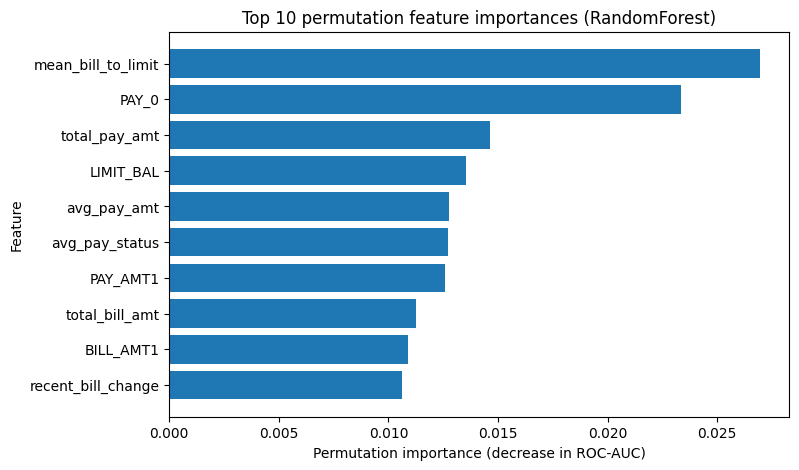

In [ ]:
#Visualization 1: Top feature importances:
top_n = 10
top_imp = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.xlabel("Permutation importance (decrease in ROC-AUC)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} permutation feature importances ({best_model_name})")
plt.show()

-- The permutation importance plot shows that only a small group of features contributes most of the predictive power, with repayment-status and payment/billing behavior features typically ranking highest.

In [ ]:
y_interp_pred_proba = best_optimized_model.predict_proba(X_interp)[:, 1]

interp_analysis_df = X_interp.copy()
interp_analysis_df["y_true"] = y_interp.values
interp_analysis_df["pred_proba_default"] = y_interp_pred_proba

interp_analysis_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,any_month_late,avg_bill_amt,avg_pay_amt,total_bill_amt,total_pay_amt,mean_bill_to_limit,pay_to_bill_ratio_total,recent_bill_change,y_true,pred_proba_default
19167,19168,200000.0,2,3,2,33,1,2,2,2,...,1,54398.833333,2183.333333,326393.0,13100.0,0.271994,0.040136,-5158.0,1,0.546333
9431,9432,430000.0,2,2,1,43,-1,-1,-1,0,...,0,13068.666667,9495.666667,78412.0,56974.0,0.030392,0.726589,-7268.0,0,0.058004
19154,19155,230000.0,2,2,1,37,0,0,0,0,...,0,36941.833333,5925.000000,221651.0,35550.0,0.160617,0.160387,32999.0,0,0.068485
12487,12488,90000.0,2,3,1,46,-2,-2,-2,-2,...,0,1376.166667,1336.666667,8257.0,8020.0,0.015291,0.971179,923.0,0,0.121836
27810,27811,30000.0,2,2,2,25,0,0,0,0,...,0,16070.000000,1958.166667,96420.0,11749.0,0.535667,0.121851,-2466.0,0,0.131563


In [ ]:
exclude_for_trend = {"ID", "SEX", "EDUCATION", "MARRIAGE"}

candidate_top_features = [
    f for f in importance_df["feature"].tolist()
    if f not in exclude_for_trend
]

top_trend_features = candidate_top_features[:3]
print("Top features selected for trend analysis:", top_trend_features)

Top features selected for trend analysis: ['mean_bill_to_limit', 'PAY_0', 'total_pay_amt']



Trend summary for mean_bill_to_limit:


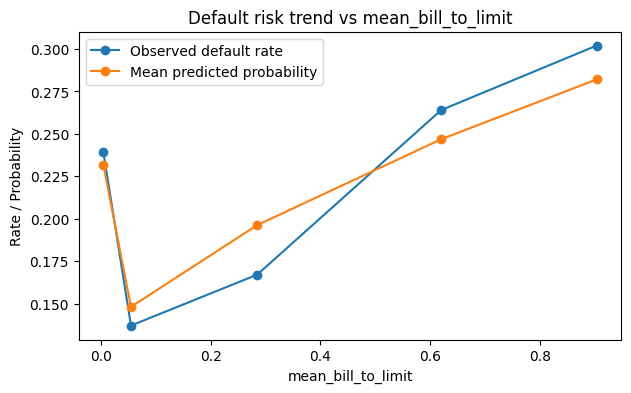

,bin,mean_feature,observed_default_rate,mean_pred_prob,count
0,"(-0.201, 0.0157]",0.0044,0.239,0.2315,1000
1,"(0.0157, 0.126]",0.0546,0.137,0.1480,1000
2,"(0.126, 0.459]",0.2847,0.167,0.1962,1000
3,"(0.459, 0.763]",0.6201,0.264,0.2468,1000
4,"(0.763, 1.86]",0.9035,0.302,0.2821,1000



Trend summary for PAY_0:


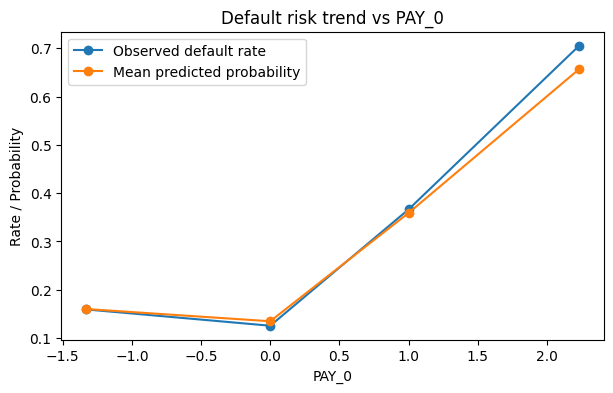

,bin,mean_feature,observed_default_rate,mean_pred_prob,count
0,"(-2.001, -1.0]",-1.3319,0.1591,0.1599,1389
1,"(-1.0, 0.0]",0.0000,0.1253,0.1346,2506
2,"(0.0, 1.0]",1.0000,0.3663,0.3590,606
3,"(1.0, 8.0]",2.2325,0.7054,0.6569,499



Trend summary for total_pay_amt:


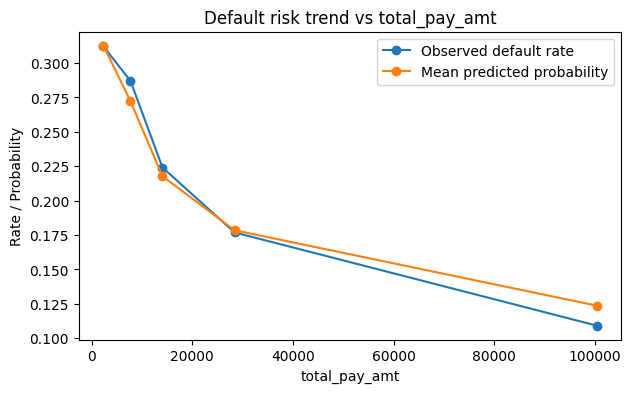

,bin,mean_feature,observed_default_rate,mean_pred_prob,count
0,"(-0.001, 5380.2]",2328.0120,0.3120,0.3126,1000
1,"(5380.2, 10096.8]",7699.5670,0.2870,0.2723,1000
2,"(10096.8, 19408.2]",14065.8820,0.2240,0.2176,1000
3,"(19408.2, 40000.0]",28384.9650,0.1768,0.1784,1001
4,"(40000.0, 704208.0]",100368.6717,0.1091,0.1236,999


In [ ]:
#Visualization 2: Binned trend plots for top features
def plot_binned_trend(df, feature, target_col="y_true", pred_col="pred_proba_default", q=5):
    temp = df[[feature, target_col, pred_col]].copy()
    
    temp["bin"] = pd.qcut(temp[feature], q=q, duplicates="drop")
    
    summary = temp.groupby("bin", observed=False).agg(
        mean_feature=(feature, "mean"),
        observed_default_rate=(target_col, "mean"),
        mean_pred_prob=(pred_col, "mean"),
        count=(feature, "size")
    ).reset_index()
    
    plt.figure(figsize=(7, 4))
    plt.plot(summary["mean_feature"], summary["observed_default_rate"], marker="o", label="Observed default rate")
    plt.plot(summary["mean_feature"], summary["mean_pred_prob"], marker="o", label="Mean predicted probability")
    plt.xlabel(feature)
    plt.ylabel("Rate / Probability")
    plt.title(f"Default risk trend vs {feature}")
    plt.legend()
    plt.show()
    
    return summary

trend_summaries = {}

for feat in top_trend_features:
    print(f"\nTrend summary for {feat}:")
    summary_df = plot_binned_trend(interp_analysis_df, feat, q=5)
    display(summary_df.round(4))
    trend_summaries[feat] = summary_df

#### Summarize:

To interpret a non-linear model, I examined the optimized Random Forest model from Q10 using permutation importance with ROC-AUC as the scoring metric. I used this method because it is model-agnostic and measures how much model performance decreases when each feature is randomly shuffled. I computed permutation importance on a random subset of 5,000 training examples to reduce runtime.

The permutation importance results showed that the most important features included mean_bill_to_limit, PAY_0, total_pay_amt, LIMIT_BAL, avg_pay_amt, avg_pay_status, PAY_AMT1, total_bill_amt, BILL_AMT1, and recent_bill_change. Overall, the top-ranked features were mainly related to repayment status and payment/billing behavior, which is consistent with the credit default prediction task.

To understand how important features influence predictions, I examined binned trend plots for the top three trend-analysis features: mean_bill_to_limit, PAY_0, and total_pay_amt. For PAY_0, both the observed default rate and the model’s predicted default probability increased sharply as repayment status worsened, showing that recent delinquency is a strong risk signal. For total_pay_amt, the observed default rate and predicted probability decreased as total payment amount increased from about 0.3120 in the lowest-payment bin to 0.1091 in the highest-payment bin, suggesting that higher recent payments are associated with lower default risk.

For mean_bill_to_limit, the relationship was non-linear: the observed and predicted risk were relatively low at low-to-moderate values and increased at higher values, with the highest bin showing the highest risk, which observed default rate about 0.302. This suggests that clients with larger average bill amounts relative to their credit limit are more likely to default.

Overall, the interpretation results suggest that the Random Forest model relies most on features that capture recent delinquency severity, payment behavior, and bill amounts relative to available credit, which are all reasonable predictors for credit default risk. This increases my confidence that the model is learning meaningful patterns rather than relying on arbitrary signals.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:


print("Best model from Q10:", best_model_name)

best_optimized_model.fit(X_train_fe, y_train)

y_test_pred = best_optimized_model.predict(X_test_fe)
y_test_proba = best_optimized_model.predict_proba(X_test_fe)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_proba)
}

test_summary = pd.DataFrame({
    "metric": list(test_metrics.keys()),
    "test_score": list(test_metrics.values())
})

print("Test-set performance:")
display(test_summary.round(4))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

Best model from Q10: RandomForest
Test-set performance:


,metric,test_score
0,accuracy,0.8233
1,precision,0.6919
2,recall,0.3631
3,f1,0.4763
4,roc_auc,0.7871


Confusion matrix [[TN, FP], [FN, TP]]:
[[6687  322]
 [1268  723]]


In [ ]:
best_model_row_q10 = optimized_summary.loc[
    optimized_summary["model"].str.contains(best_model_name, regex=False)
].iloc[0]

validation_vs_test = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "validation_cv_mean": [
        best_model_row_q10["cv_accuracy_mean"],
        best_model_row_q10["cv_precision_mean"],
        best_model_row_q10["cv_recall_mean"],
        best_model_row_q10["cv_f1_mean"],
        best_model_row_q10["cv_roc_auc_mean"]
    ],
    "validation_cv_std": [
        best_model_row_q10["cv_accuracy_std"],
        best_model_row_q10["cv_precision_std"],
        best_model_row_q10["cv_recall_std"],
        best_model_row_q10["cv_f1_std"],
        best_model_row_q10["cv_roc_auc_std"]
    ],
    "test_score": [
        test_metrics["accuracy"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["f1"],
        test_metrics["roc_auc"]
    ]
})

validation_vs_test["test_minus_validation"] = (
    validation_vs_test["test_score"] - validation_vs_test["validation_cv_mean"]
)

validation_vs_test.round(4)

,metric,validation_cv_mean,validation_cv_std,test_score,test_minus_validation
0,accuracy,0.8185,0.0002,0.8233,0.0049
1,precision,0.6677,0.0059,0.6919,0.0242
2,recall,0.3574,0.0106,0.3631,0.0058
3,f1,0.4654,0.0077,0.4763,0.0109
4,roc_auc,0.7822,0.0066,0.7871,0.0050


In [ ]:
test_pred_df = X_test_fe.copy()
test_pred_df["y_true"] = y_test.values
test_pred_df["y_pred"] = y_test_pred
test_pred_df["pred_proba_default"] = y_test_proba

test_pred_df[["y_true", "y_pred", "pred_proba_default"]].head()

,y_true,y_pred,pred_proba_default
45,1,0,0.304254
18762,0,0,0.094883
9341,0,0,0.132639
21814,0,0,0.246039
25950,0,0,0.092197


In [ ]:
tp_candidates = test_pred_df[(test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 1)]
tn_candidates = test_pred_df[(test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 0)]

if len(tp_candidates) > 0:
    idx_case_high_risk = tp_candidates.sort_values("pred_proba_default", ascending=False).index[0]
else:
    idx_case_high_risk = test_pred_df.sort_values("pred_proba_default", ascending=False).index[0]

if len(tn_candidates) > 0:
    idx_case_low_risk = tn_candidates.sort_values("pred_proba_default", ascending=True).index[0]
else:
    idx_case_low_risk = test_pred_df.sort_values("pred_proba_default", ascending=True).index[0]

selected_case_indices = [idx_case_high_risk, idx_case_low_risk]

print("Selected case indices:", selected_case_indices)

key_cols_for_cases = [
    "y_true", "y_pred", "pred_proba_default",
    "PAY_0", "avg_pay_status", "num_months_late",
    "mean_bill_to_limit", "total_pay_amt", "total_bill_amt", "LIMIT_BAL"
]

key_cols_for_cases = [c for c in key_cols_for_cases if c in test_pred_df.columns]

display(test_pred_df.loc[selected_case_indices, key_cols_for_cases].round(4))

Selected case indices: [np.int64(27536), np.int64(21496)]


,y_true,y_pred,pred_proba_default,PAY_0,avg_pay_status,num_months_late,mean_bill_to_limit,total_pay_amt,total_bill_amt,LIMIT_BAL
27536,1,1,0.9253,3,2.1667,6,0.0099,0.0,14922.0,250000.0
21496,0,0,0.0358,0,0.0000,0,0.1398,135007.0,419364.0,500000.0


#### Summarize:

I evaluated my best-performing model from Q10, the optimized Random Forest, on the held-out test set. I fit the model on the full training set and then computed the test metrics using the same evaluation metrics as before.

The test-set performance was: accuracy = 0.8233, precision = 0.6919, recall = 0.3631, F1-score = 0.4763, and ROC-AUC = 0.7871. These results indicate that the model performs substantially better than the baseline and remains strong on unseen test data.

To assess consistency, I compared the test scores with the validation scores from Q10. The optimized Random Forest had validation ROC-AUC = 0.7822, and the test ROC-AUC was 0.7871. The differences between validation and test scores were small, which suggests that the model’s performance is reasonably consistent when moving from validation to the final test set. Overall, I do trust these results, with the caveat that I performed multiple rounds of model comparison and hyperparameter tuning, so some optimization bias may still be present.

The confusion matrix on the test set was [[6687, 322], [1268, 723]], which shows that the model correctly identified many non-default cases and a meaningful number of default cases, although it still missed some positives. This is consistent with the moderate recall value.

For individual prediction explanations, I selected two test examples: one correctly predicted high-risk default case and one correctly predicted low-risk non-default case. The high-risk case (index 27536) had a predicted default probability of 0.9253 and showed strong risk signals: PAY_0 = 3, avg_pay_status = 2.1667, num_months_late = 6, and total_pay_amt = 0. This is consistent with the Q11 interpretation, where worse repayment status (higher PAY_0) increased default risk and lower payment amounts were associated with higher risk.

The low-risk case (index 21496) had a predicted default probability of 0.0358 and was correctly predicted as non-default. Its feature values showed safer behavior: PAY_0 = 0, avg_pay_status = 0.0000, num_months_late = 0, and a very high total_pay_amt = 135007. This also matches the Q11 trends, where better recent repayment status and higher total payments were associated with lower default risk.

These example-level explanations are consistent with the global interpretation results from Q11 and increase confidence that the model is making predictions based on meaningful repayment and payment/billing behavior patterns.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [ ]:
summary_results_q13 = pd.DataFrame([
    {
        "Model": "DummyClassifier (baseline)",
        "Validation / CV ROC-AUC": 0.5000,
        "Validation / CV F1": 0.0000,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Always predicts majority class; high accuracy but no usefulness for defaults"
    },
    {
        "Model": "LogisticRegression (Q7 best linear)",
        "Validation / CV ROC-AUC": 0.7579,
        "Validation / CV F1": 0.4063,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Strong linear benchmark; stable across C values"
    },
    {
        "Model": "DecisionTree (Q8)",
        "Validation / CV ROC-AUC": 0.6103,
        "Validation / CV F1": 0.3942,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Strong overfitting (near-perfect train accuracy, weak validation performance)"
    },
    {
        "Model": "KNN (Q8)",
        "Validation / CV ROC-AUC": 0.7399,
        "Validation / CV F1": 0.4404,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Reasonable performance; slower scoring time"
    },
    {
        "Model": "RandomForest (Q8)",
        "Validation / CV ROC-AUC": 0.7691,
        "Validation / CV F1": 0.4702,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Best non-linear model before tuning; outperformed logistic regression on ROC-AUC"
    },
    {
        "Model": "LogisticRegression + RFECV (Q9)",
        "Validation / CV ROC-AUC": 0.7577,
        "Validation / CV F1": 0.4062,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Feature selection selected 40/44 features; no meaningful improvement"
    },
    {
        "Model": "Optimized LogisticRegression (Q10)",
        "Validation / CV ROC-AUC": 0.7596,
        "Validation / CV F1": 0.5229,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Balanced class_weight greatly increased recall/F1, but lowered precision/accuracy"
    },
    {
        "Model": "Optimized KNN (Q10)",
        "Validation / CV ROC-AUC": 0.7581,
        "Validation / CV F1": 0.4473,
        "Test ROC-AUC": np.nan,
        "Test F1": np.nan,
        "Key observation": "Improved from untuned KNN, but not best overall"
    },
    {
        "Model": "Optimized RandomForest (Q10/Q12 FINAL)",
        "Validation / CV ROC-AUC": 0.7822,
        "Validation / CV F1": 0.4654,
        "Test ROC-AUC": 0.7871,
        "Test F1": 0.4763,
        "Key observation": "Best model by ROC-AUC; validation and test performance are consistent"
    }
])

summary_results_q13.round(4)

,Model,Validation / CV ROC-AUC,Validation / CV F1,Test ROC-AUC,Test F1,Key observation
0,DummyClassifier (baseline),0.5000,0.0000,NaN,NaN,Always predicts majority class; high accuracy ...
1,LogisticRegression (Q7 best linear),0.7579,0.4063,NaN,NaN,Strong linear benchmark; stable across C values
2,DecisionTree (Q8),0.6103,0.3942,NaN,NaN,Strong overfitting (near-perfect train accurac...
3,KNN (Q8),0.7399,0.4404,NaN,NaN,Reasonable performance; slower scoring time
4,RandomForest (Q8),0.7691,0.4702,NaN,NaN,Best non-linear model before tuning; outperfor...
5,LogisticRegression + RFECV (Q9),0.7577,0.4062,NaN,NaN,Feature selection selected 40/44 features; no ...
6,Optimized LogisticRegression (Q10),0.7596,0.5229,NaN,NaN,Balanced class_weight greatly increased recall...
7,Optimized KNN (Q10),0.7581,0.4473,NaN,NaN,"Improved from untuned KNN, but not best overall"
8,Optimized RandomForest (Q10/Q12 FINAL),0.7822,0.4654,0.7871,0.4763,Best model by ROC-AUC; validation and test per...


#### Task 2:

In this project, I compared baseline, linear, and non-linear models for predicting credit card default. The `DummyClassifier` confirmed that accuracy alone is misleading because the dataset is imbalanced. Logistic regression provided a strong and stable linear benchmark, while Random Forest produced the best overall ROC-AUC among the non-linear models.

I also explored feature selection and hyperparameter tuning. RFECV with logistic regression did not meaningfully improve performance, which suggests that the engineered feature set was already reasonably effective. Hyperparameter optimization improved several models, especially Random Forest (higher ROC-AUC) and logistic regression with class_weight='balanced' (higher recall and F1-score due to a different precision-recall trade-off).

Overall, the optimized Random Forest was the strongest final model based on my chosen selection metric (ROC-AUC), and its test performance was consistent with validation performance, which increases confidence in the final result.

#### Task 3:

There are several improvements I did not try that could potentially improve model performance or interpretability. I could tune the classification threshold instead of using the default 0.5 to better balance precision and recall depending on the business goal. For example, identifying more defaults vs reducing false alarms.

#### Task 4:
My final selected model is the optimized Random Forest from Q10. I used ROC-AUC as the main metric for model selection because this is an imbalanced binary classification problem and ROC-AUC evaluates class separation across thresholds.

The final test-set results for the optimized Random Forest were:

- ROC-AUC = 0.7871 (main metric)

- Accuracy = 0.8233

- Precision = 0.6919

- Recall = 0.3631

- F1-score = 0.4763

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

### My thoughts:

My biggest takeaway is that the full workflow matters more than just trying fancier models. In this project, I learned that data splitting, preprocessing, choosing proper evaluation metrics, and using cross-validation correctly can matter just as much as the model itself.

Another important takeaway is that metrics must match the problem. Because this dataset is imbalanced, accuracy alone looked misleadingly good for the baseline model, while metrics like ROC-AUC, recall, and F1-score gave a much clearer picture of model quality.

I also learned that model comparison is really about trade-offs. For example, logistic regression was simple and strong, Random Forest performed better on ROC-AUC, and tuning changed the precision-recall balance. This helped me understand that there is usually no single perfect model that fits the goal best.

Finally, I think the most useful thing I learned is how to build a reproducible pipeline and interpret the results instead of only reporting a score. That feels much closer to how a real machine learning project works.

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)